In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Rectangle
import numpy as np
import matplotlib.colors as colors
import geopandas as gpd
import os

# Membaca file CSV
file_path          = "/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/02.output/03.Indice/STATS_1981-01-01_2024-12-31.csv"
DataBatas          = '/mnt/dataset/01_ANALISA/02.Climate_Indices_Analysis_For_Projection_Dataset/data/batas'
ShapefilePath      = os.path.join(DataBatas, 'BATAS_PROVINSI_DESEMBER_2019_DUKCAPIL.shp')
shapefile_lautpath = '/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Garis Pantai 50K (Garis) 2021.shp'

pm25               = pd.read_csv(file_path)
shapefile          = gpd.read_file(ShapefilePath)

LAUT = gpd.read_file(shapefile_lautpath)
TL   =  gpd.read_file("/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Negara_Tetangga/BatasDarat_RI_RDTL.shp")
ML   =  gpd.read_file("/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Negara_Tetangga/BatasDarat_RIMalaysia.shp")
PNG  =  gpd.read_file("/mnt/dataset/01_ANALISA/01.Climate_Indices_Analysis_For_Observation_Dataset/01.data/05.Spasial/Negara_Tetangga/BatasDarat_RI_PNG.shp")

# Pastikan CRS adalah EPSG:4326 (latlon)
for shp in [PNG, TL, ML, LAUT]:
    if shp.crs != "EPSG:4326":
        shp.to_crs("EPSG:4326", inplace=True)



In [ ]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

# Plotting 2070 projected August (8) precip from worldclim
gdata = gdal.Open("D:/jon/datasets/worldclim/future/pr/gf45pr70_usa/gf45pr708.tif")
geo = gdata.GetGeoTransform()
data = gdata.ReadAsArray()

xres = geo[1]
yres = geo[5]

# A good LCC projection for USA plots
m = Basemap(llcrnrlon=-119,llcrnrlat=22,urcrnrlon=-64,urcrnrlat=49,
            projection='lcc',lat_1=33,lat_2=45,lon_0=-95)

# This just plots the shapefile -- it has already been clipped
m.readshapefile('D:/jon/datasets/USGS HUCs/US_states/states','states',drawbounds=True, color='0.3')

xmin = geo[0] + xres * 0.5
xmax = geo[0] + (xres * gdata.RasterXSize) - xres * 0.5
ymin = geo[3] + (yres * gdata.RasterYSize) + yres * 0.5
ymax = geo[3] - yres * 0.5

x,y = np.mgrid[xmin:xmax+xres:xres, ymax+yres:ymin:yres]
x,y = m(x,y)

cmap = plt.cm.gist_rainbow
cmap.set_under ('1.0')
cmap.set_bad('0.8')

im = m.pcolormesh(x,y, data.T, cmap=cmap, vmin=0, vmax=100)

cb = plt.colorbar( orientation='vertical', fraction=0.10, shrink=0.7)
plt.title('August Precip (mm)')
plt.show()

Note:Caching=1


SyntaxError: keyword argument repeated: projection (585014810.py, line 29)

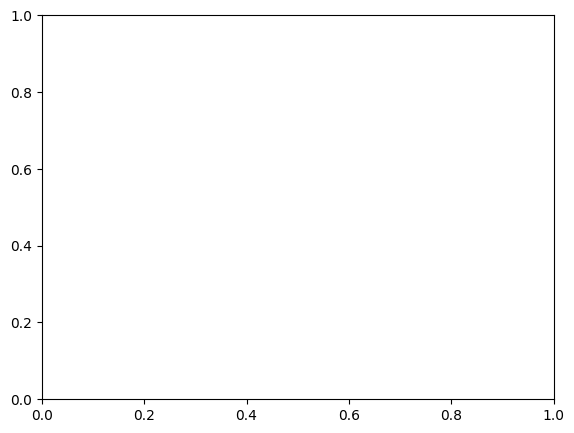

In [ ]:
from mpl_toolkits.basemap import Basemap, shiftgrid, cm
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

# read in etopo5 topography/bathymetry.
url = 'http://ferret.pmel.noaa.gov/thredds/dodsC/data/PMEL/etopo5.nc'
etopodata = Dataset(url)

topoin = etopodata.variables['ROSE'][:]
lons   = etopodata.variables['ETOPO05_X'][:]
lats   = etopodata.variables['ETOPO05_Y'][:]
# shift data so lons go from -180 to 180 instead of 20 to 380.
topoin,lons = shiftgrid(180.,topoin,lons,start=False)

# plot topography/bathymetry as an image.

# create the figure and axes instances.
fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])
# setup of basemap ('lcc' = lambert conformal conic).
# use major and minor sphere radii from WGS84 ellipsoid.
m = Basemap(projection='mill',
            llcrnrlat=-15,
            urcrnrlat=11,
            llcrnrlon=92,
            urcrnrlon=145,
            rsphere=(6378137.00,6356752.3142),
            resolution='l',area_thresh=1000,
            lat_1=50.,lon_0=-107.,ax=ax)
# transform to nx x ny regularly spaced 5km native projection grid
nx = int((m.xmax-m.xmin)/5000.)+1; ny = int((m.ymax-m.ymin)/5000.)+1
topodat = m.transform_scalar(topoin,lons,lats,nx,ny)
# plot image over map with imshow.
im = m.imshow(topodat,cm.GMT_haxby)
# draw coastlines and political boundaries.
m.drawcoastlines()
m.drawcountries()
m.drawstates()
# draw parallels and meridians.
# label on left and bottom of map.
parallels = np.arange(0.,80,20.)
m.drawparallels(parallels,labels=[1,0,0,1])
meridians = np.arange(10.,360.,30.)
m.drawmeridians(meridians,labels=[1,0,0,1])
# add colorbar
cb = m.colorbar(im,"right", size="5%", pad='2%')
ax.set_title('ETOPO5 Topography - Lambert Conformal Conic')
plt.show()

In [52]:
import cmocean.cm as cmo
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Fungsi formatter untuk garis lintang (parallels)
def deg_to_degmin_lat(x):
    """Konversi derajat desimal ke string derajat-menit (° ' ) untuk lintang."""
    is_neg = x < 0
    x = abs(x)
    deg = int(x)
    minute = round((x - deg) * 60)  # Konversi ke menit
    
    if deg == 0:
        sign = '0"'
        return f"{deg}°{minute:02d}'"  # Tanpa arah jika derajat = 0
    else:
        sign = '0"S' if is_neg else '0"N'
        return f"{deg}°{minute:01d}'{sign}"

# Fungsi formatter untuk garis bujur (meridians)
def deg_to_degmin_lon(x):
    """Konversi derajat desimal ke string derajat-menit (° ' ) untuk bujur."""
    is_neg = x < 0
    x = abs(x)
    deg = int(x)
    minute = round((x - deg) * 60)  # Konversi ke menit
    sign = 'W' if is_neg else '0"E'
    return f"{deg}°{minute:01d}'{sign}"

def plot_shape_boundary(shape, color='#808080', linewidth=2, linestyle='solid', zorder=2, alpha=0.5):
    for _, row in shape.iterrows():
        geom = row.geometry
        x, y = m(geom.xy[0], geom.xy[1])
        m.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle, zorder=zorder, alpha=alpha,transform=ccrs.PlateCarree())

CRS shapefile: EPSG:4326


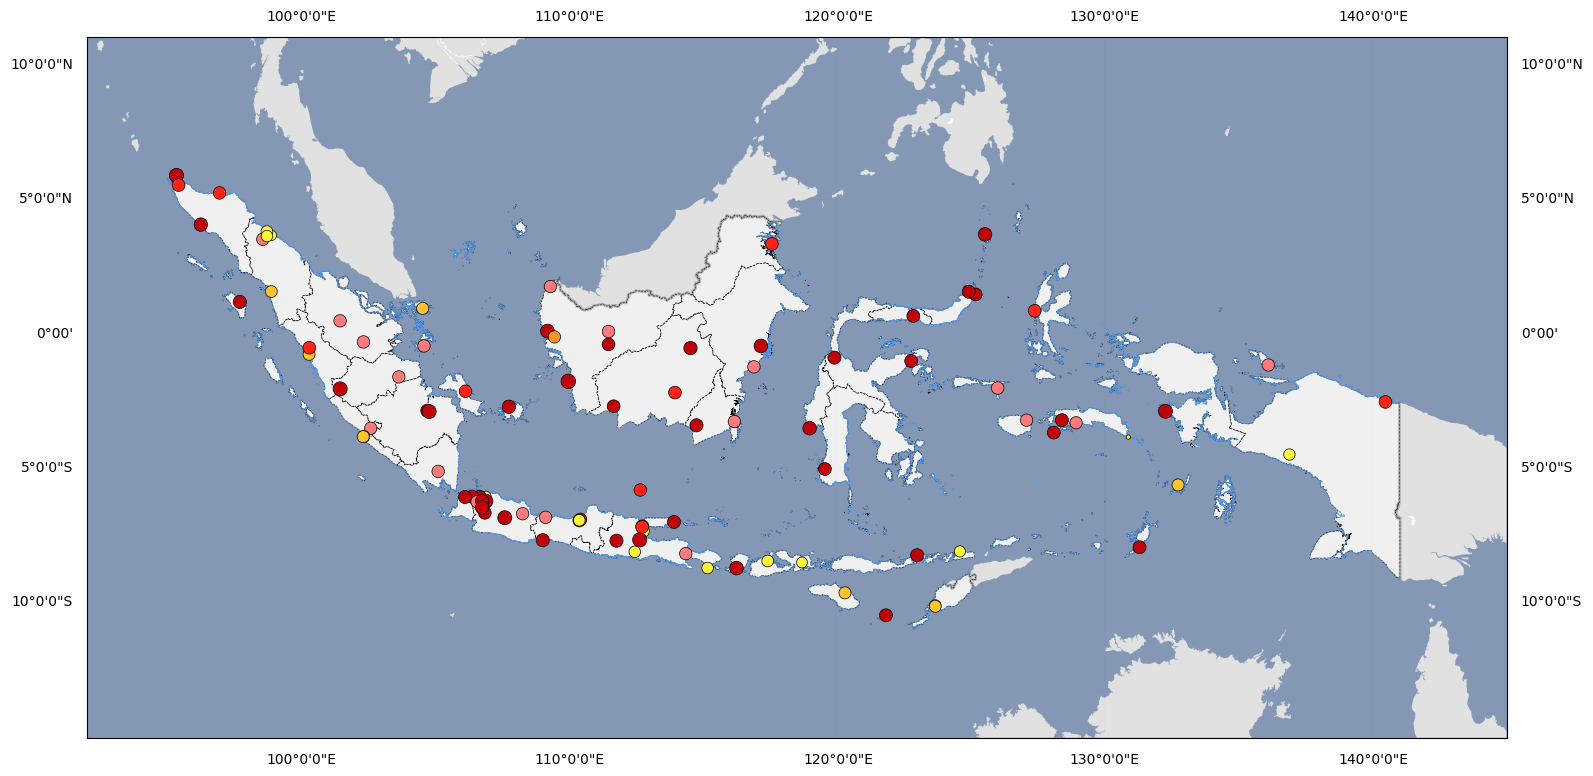

In [ ]:
# Konversi LAT dan LON menjadi float
pm25['LAT'] = pm25['LAT'].astype(float)
pm25['LON'] = pm25['LON'].astype(float)

# Pastikan kolom TXx dalam format numerik
pm25['TXx'] = pd.to_numeric(pm25['TXx'], errors='coerce')

# Cek dan pastikan CRS sesuai (tidak perlu konversi karena EPSG:4326)
print("CRS shapefile:", shapefile.crs)  # Harus menunjukkan EPSG:4326 [[10]]

# Buat figure
plt.figure(figsize=(16, 8))

# Inisialisasi Basemap dengan proyeksi Miller
m = Basemap(projection='mill',
            llcrnrlat=-15,
            urcrnrlat=11,
            llcrnrlon=92,
            urcrnrlon=145,
            resolution='i')

# Gambar komponen peta
m.drawcountries(linewidth=0.0)
m.fillcontinents(color='#e1e1e1', lake_color='white')

# Draw parallels and meridians
parallels = range(-90, 91, 5)  # Interval 10 derajat untuk lintang
meridians = range(-180, 181, 10)  # Interval 20 derajat untuk bujur

# Buat formatter
fmt_lat = mticker.FuncFormatter(lambda x, pos: deg_to_degmin_lat(x))
fmt_lon = mticker.FuncFormatter(lambda x, pos: deg_to_degmin_lon(x))

# Gambar grid
m.drawparallels(parallels, labels=[1,1,1,1], linewidth=0.01, fontsize=10, fmt=fmt_lat)
m.drawmeridians(meridians, labels=[1,1,1,1], linewidth=0.01, fontsize=10, fmt=fmt_lon)

# plot image over map with imshow.
topodat = m.transform_scalar(topoin,lons,lats,nx,ny)
im      = m.imshow(topodat, cmap='Blues_r', alpha=0.5)

#PLOTING BATAS NEGARA
plot_shape_boundary(PNG)
plot_shape_boundary(TL)
plot_shape_boundary(ML)

# 🔹 Tambahkan shapefile menggunakan GeoPandas
for _, row in shapefile.iterrows():
    geom = row.geometry
    
    if geom.geom_type == 'Polygon':
        x, y = m(geom.exterior.coords.xy[0].tolist(), geom.exterior.coords.xy[1].tolist())
        poly = plt.Polygon(list(zip(x, y)), facecolor='#f0f0f0', edgecolor='black', linewidth=0.5, zorder=1, linestyle='--')
        plt.gca().add_patch(poly)
        
    elif geom.geom_type == 'MultiPolygon':
        for polygon in geom.geoms:
            x, y = m(polygon.exterior.coords.xy[0].tolist(), polygon.exterior.coords.xy[1].tolist())
            poly = plt.Polygon(list(zip(x, y)), facecolor='#f0f0f0', edgecolor='black', linewidth=0.5, zorder=1, linestyle='--')
            plt.gca().add_patch(poly)
    
    elif geom.geom_type == 'LineString':
        x, y = m(geom.xy[0], geom.xy[1])
        m.plot(x, y, color='#599ae2', linewidth=0.5, linestyle='--', zorder=1)

#plot batas laut
plot_shape_boundary(shapefile_laut, color='#599ae2', linewidth=0.5, linestyle='--', zorder=1, alpha=1)

# Konversi koordinat geografis ke proyeksi peta
xs, ys = m(pm25['LON'].values, pm25['LAT'].values)

# Rentang nilai dan warna untuk TXx
bounds      = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]
colors_list = ["#f8f53a", "#fec42f", "#ff9425","#ff7a7c", "#ff2415","#bf030b","#bf030b"]
cmap        = colors.ListedColormap(colors_list)
norm        = colors.BoundaryNorm(bounds, cmap.N)

# Hitung ukuran bulatan berdasarkan TXx
sizes = (pm25['TXx'] - pm25['TXx'].min()) / (pm25['TXx'].max() - pm25['TXx'].min())
sizes = sizes * 100 + 10  # Skala ukuran antara 20 hingga 150

# Plot scatter
sc = m.scatter(xs, ys, c=pm25['TXx'] * 44, cmap=cmap, norm=norm, s=sizes, alpha=1, edgecolors='k', linewidths=0.5, zorder=2)

# Tambahkan colorbar
# cb = m.colorbar(sc, location='bottom', pad="10%", extend='both')
# cb.set_label('Nilai TXx (°C)', fontsize=12)
# cb.ax.tick_params(labelsize=10)

# Tambahkan legenda ukuran (dummy plot)
# for size in [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]:
#     scaled_size = ((size - pm25['TXx'].min()) / (pm25['TXx'].max() - pm25['TXx'].min())) * 100 + 5
#     plt.scatter([], [], c='gray', alpha=0.7, s=scaled_size, label=f'{size}°C', edgecolors='k', linewidth=0.5)

# Hilangkan garis kotak pinggir plot
# for spine in plt.gca().spines.values():
#     spine.set_visible(False)

# Add domain rectangle
from matplotlib.patches import Rectangle
domain_rect = Rectangle((92, -15), 
                        145 - 93, 
                        11 - -15,
                        linewidth=4, edgecolor='black', facecolor='none', linestyle='solid')

plt.gca().add_patch(domain_rect)

# Ubah orientasi label parallels (lintang) menjadi vertikal
for label in plt.gca().get_yticklabels():
    label.set_rotation(90)  # Rotasi 90 derajat (vertikal)
    
# Judul dan layout
plt.title("", fontsize=14, pad=20)
plt.tight_layout()
# plt.subplots_adjust(right=0.85)
# plt.savefig("test.svg", format="svg", tras)
plt.show()

In [81]:
# Konversi LAT dan LON menjadi float
pm25['LAT'] = pm25['LAT'].astype(float)
pm25['LON'] = pm25['LON'].astype(float)

# Pastikan kolom TXx dalam format numerik
pm25['TXx'] = pd.to_numeric(pm25['TXx'], errors='coerce')


# Konversi koordinat geografis ke proyeksi peta
xs, ys = m(pm25['LON'].values, pm25['LAT'].values)

# Rentang nilai dan warna untuk TXx
bounds      = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]
colors_list = ["#f8f53a", "#fec42f", "#ff9425","#ff7a7c", "#ff2415","#bf030b","#bf030b"]
cmap        = colors.ListedColormap(colors_list)
norm        = colors.BoundaryNorm(bounds, cmap.N)

# Hitung ukuran bulatan berdasarkan TXx
sizes = (pm25['TXx'] - pm25['TXx'].min()) / (pm25['TXx'].max() - pm25['TXx'].min())
sizes = sizes * 100 + 10  # Skala ukuran antara 20 hingga 150

# Plot scatter
sc = m.scatter(xs, ys, c=pm25['TXx'] * 44, cmap=cmap, norm=norm, s=sizes, alpha=1, edgecolors='k', linewidths=0.5, zorder=2)

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature

shp_indo     = ShapelyFeature(Reader(ShapefilePath).geometries(), ccrs.PlateCarree())
garis_pantai = ShapelyFeature(Reader(shapefile_lautpath).geometries(), ccrs.PlateCarree())

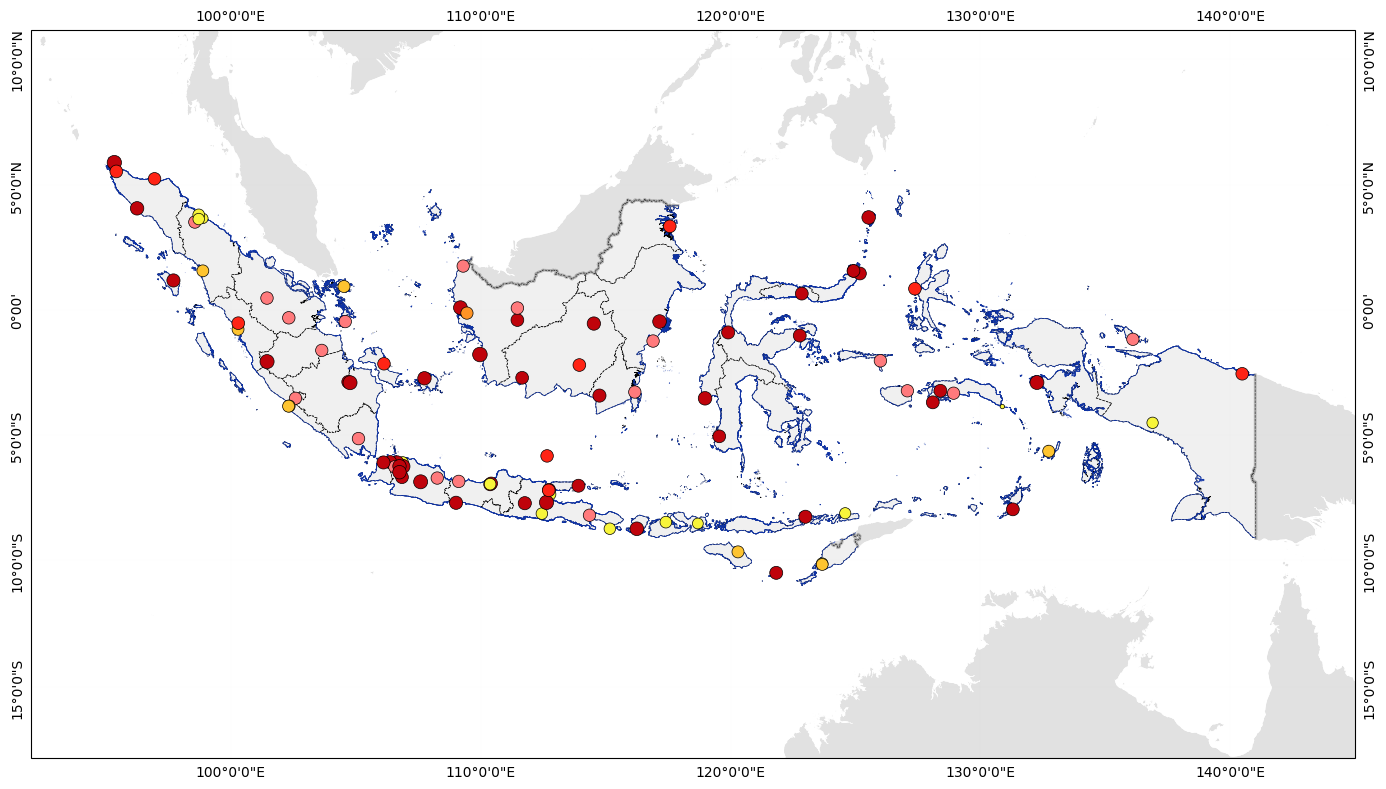

In [102]:
# Fungsi formatter untuk garis lintang (parallels)
def deg_to_degmin_lat(x):
    """Konversi derajat desimal ke string derajat-menit (° ' ) untuk lintang."""
    is_neg = x < 0
    x = abs(x)
    deg = int(x)
    minute = round((x - deg) * 60)  # Konversi ke menit
    
    if deg == 0:
        sign = '0"'
        return f"{deg}°{minute:02d}'"  # Tanpa arah jika derajat = 0
    else:
        sign = '0"S' if is_neg else '0"N'
        return f"{deg}°{minute:01d}'{sign}"

# Fungsi formatter untuk garis bujur (meridians)
def deg_to_degmin_lon(x):
    """Konversi derajat desimal ke string derajat-menit (° ' ) untuk bujur."""
    is_neg = x < 0
    x = abs(x)
    deg = int(x)
    minute = round((x - deg) * 60)  # Konversi ke menit
    sign = '0"W' if is_neg else '0"E'
    return f"{deg}°{minute:01d}'{sign}"

# Plot Batasa Negara
def plot_shape_boundary(shape, color='#599ae2', linewidth=0.5, linestyle='--', zorder=2, alpha=1):
    for _, row in shape.iterrows():
        geom = row.geometry
        if geom.geom_type == 'LineString':
            x, y = geom.xy
            ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                    transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)
        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                        transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)
        elif geom.geom_type == 'Polygon':
            x, y = geom.exterior.xy
            ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle,
                    transform=ccrs.PlateCarree(), zorder=zorder, alpha=alpha)

# Buat figure dan axis dengan proyeksi PlateCarree
fig = plt.figure(figsize=(16, 8))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Miller())  # Mercator mirip Miller
ax.set_extent([92, 145, -16, 10])

# Tambahkan grid dengan custom formatter
gl              = ax.gridlines(draw_labels=True, linewidth=0.01, color='gray', alpha=0.7, linestyle='--')
gl.xlocator     = mticker.FixedLocator(range(90, 150, 10))
gl.ylocator     = mticker.FixedLocator(range(-15, 12, 5))
gl.xformatter   = mticker.FuncFormatter(lambda x, pos: deg_to_degmin_lon(x))
gl.yformatter   = mticker.FuncFormatter(lambda x, pos: deg_to_degmin_lat(x))

# Format label
gl.xlabel_style = {'rotation':0,'color': 'black', 'size': 10}
gl.ylabel_style = {'rotation': 90, 'color': 'black', 'size': 10}

# Tambahkan fitur dasar peta
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#e1e1e1')
ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='white')

# plot_shape_boundary(shapefile, linewidth=2, linestyle='solid', color='#808080')
plot_shape_boundary(PNG, linewidth=2, linestyle='solid', color='#808080', alpha=0.5)
plot_shape_boundary(TL, linewidth=2,  linestyle='solid', color='#808080', alpha=0.5)
plot_shape_boundary(ML, linewidth=2,  linestyle='solid', color='#808080', alpha=0.5)

ax.add_feature(shp_indo, facecolor='#f0f0f0', edgecolor='black', linewidth=0.5, zorder=1, linestyle='--')
ax.add_feature(garis_pantai, facecolor='none', edgecolor='#1034a6', linewidth=0.5, zorder=1, linestyle='solid')
#plot_shape_boundary(LAUT, linewidth=1, color='#1034a6', linestyle='--', zorder=1, alpha=1)

#BATAS FUNGSI#################################################################################
bounds      = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]
colors_list = ["#f8f53a", "#fec42f", "#ff9425","#ff7a7c", "#ff2415","#bf030b","#bf030b"]
cmap        = colors.ListedColormap(colors_list)
norm        = colors.BoundaryNorm(bounds, cmap.N)
# Konversi LAT dan LON menjadi float
pm25['LAT'] = pm25['LAT'].astype(float)
pm25['LON'] = pm25['LON'].astype(float)
pm25['TXx'] = pd.to_numeric(pm25['TXx'], errors='coerce')
# Hitung ukuran bulatan berdasarkan TXx
sizes       = (pm25['TXx'] - pm25['TXx'].min()) / (pm25['TXx'].max() - pm25['TXx'].min())
sizes       = sizes * 100 + 10  # Skala ukuran antara 20 hingga 150
sc          = ax.scatter(pm25['LON'], pm25['LAT'],
                c=pm25['TXx'] * 44, cmap=cmap, norm=norm, s=sizes,
                alpha=1, edgecolors='k', linewidths=0.5,
                transform=ccrs.PlateCarree(), zorder=5)
#BATAS FUNGSI#################################################################################

plt.tight_layout()
